In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]

RESULTS_DIR = None
csv_files = []
for candidate_dir in RESULTS_CANDIDATES:
    candidate_files = sorted(candidate_dir.glob(CSV_PATTERN))
    if candidate_files:
        RESULTS_DIR = candidate_dir
        csv_files = candidate_files
        break

if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    current_df["source_file"] = csv_path.name
    frames.append(current_df)

df = pd.concat(frames, ignore_index=True, sort=False)

numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "max_key",
    "nr",
    "ns",
    "partition_threads",
    "partition_throughput",
    "partition_time",
    "time_sec",
    "total_throughput",
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

fallback_total_throughput = (df["nr"] + df["ns"]) / df["time_sec"].where(df["time_sec"] > 0)
if "total_throughput" not in df.columns:
    df["total_throughput"] = fallback_total_throughput
else:
    df["total_throughput"] = df["total_throughput"].fillna(fallback_total_throughput)

exec_type_names = sorted(df["exec_type"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}

print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")

print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  max_key: {sorted(df['max_key'].dropna().unique())}")
print(f"  partition_threads: {sorted(df['partition_threads'].dropna().unique())}")
print(f"  join_threads: {sorted(df['join_threads'].dropna().unique())}")


[Loaded 152 runs from results]

Files:
  - hashjoin_par_p.csv
  - hashjoin_par_pj.csv
  - hashjoin_par_pj_wb.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['par_p', 'par_pj', 'par_pj_wb', 'seq']
  max_key: [65536, 262144]
  partition_threads: [1, 4, 8, 16, 32, 64]
  join_threads: [1, 4, 8, 16, 32, 64]


# Checksum validation

In [2]:
checksum_group_cols = ["nr", "ns", "max_key"]
summary_rows = []

for (nr, ns, max_key), subdf in df.groupby(checksum_group_cols):
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates()
    summary_rows.append({
        "nr": nr,
        "ns": ns,
        "max_key": max_key,
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(sorted(subdf["exec_type"].dropna().unique())),
    })

checksum_validation_df = (
    pd.DataFrame(summary_rows)
    .sort_values(checksum_group_cols)
    .reset_index(drop=True)
)

valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 2/2]


,nr,ns,max_key,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,65536,1,True,"par_p, par_pj, par_pj_wb, seq"
1,50000000,50000000,262144,1,True,"par_p, par_pj, par_pj_wb, seq"


# Averaging

In [3]:
group_columns = [
    "exec_type",
    "nr",
    "ns",
    "max_key",
    "partition_threads",
    "join_threads",
    "checksum1",
    "checksum2",
    "join_count",
]
avg_candidates = [
    "partition_time",
    "join_time",
    "time_sec",
    "partition_throughput",
    "join_throughput",
    "total_throughput",
]
avg_columns = [col for col in avg_candidates if col in df.columns]

stable_avg_df = (
    df.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

stable_avg_df.head(10)


,exec_type,nr,ns,max_key,partition_threads,join_threads,checksum1,checksum2,join_count,partition_time,join_time,time_sec,partition_throughput,join_throughput,total_throughput
0,par_p,50000000,50000000,65536,4,4,15384239832666499847,2938791386226452392,38147013639,0.923281,1.728507,2.654026,1.083094e+08,5.785339e+07,3.767861e+07
1,par_p,50000000,50000000,65536,4,8,15384239832666499847,2938791386226452392,38147013639,0.917350,1.729064,2.648659,1.090096e+08,5.783478e+07,3.775495e+07
2,par_p,50000000,50000000,65536,4,16,15384239832666499847,2938791386226452392,38147013639,0.917957,1.729737,2.649956,1.089376e+08,5.781227e+07,3.773648e+07
3,par_p,50000000,50000000,65536,4,32,15384239832666499847,2938791386226452392,38147013639,0.913989,1.764192,2.680497,1.094105e+08,5.668316e+07,3.730651e+07
4,par_p,50000000,50000000,65536,4,64,15384239832666499847,2938791386226452392,38147013639,0.920059,1.727600,2.649955,1.086887e+08,5.788377e+07,3.773650e+07
5,par_p,50000000,50000000,65536,8,4,15384239832666499847,2938791386226452392,38147013639,0.598678,1.729037,2.330017,1.670346e+08,5.783565e+07,4.291813e+07
6,par_p,50000000,50000000,65536,8,8,15384239832666499847,2938791386226452392,38147013639,0.602994,1.727621,2.332965,1.658391e+08,5.788306e+07,4.286391e+07
7,par_p,50000000,50000000,65536,8,16,15384239832666499847,2938791386226452392,38147013639,0.602841,1.728109,2.333253,1.658812e+08,5.786672e+07,4.285862e+07
8,par_p,50000000,50000000,65536,8,32,15384239832666499847,2938791386226452392,38147013639,0.601802,1.725065,2.329143,1.661675e+08,5.796884e+07,4.293425e+07
9,par_p,50000000,50000000,65536,8,64,15384239832666499847,2938791386226452392,38147013639,0.596932,1.726995,2.326216,1.675232e+08,5.790403e+07,4.298827e+07


# Partition time

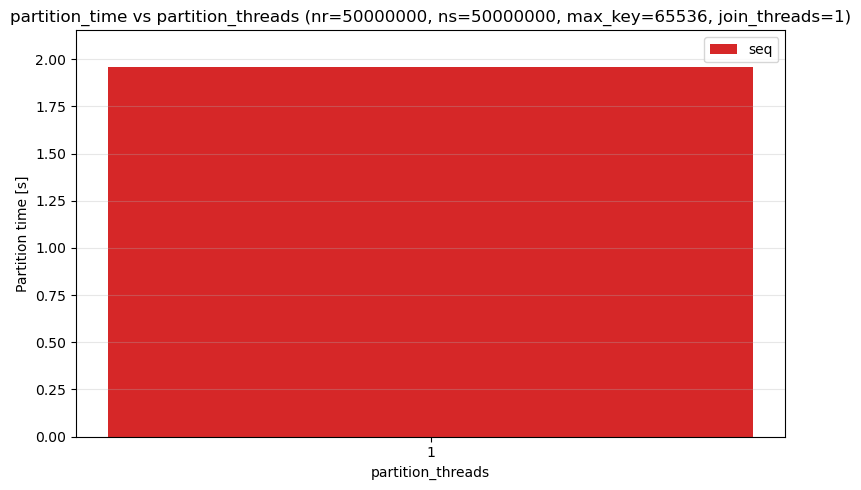

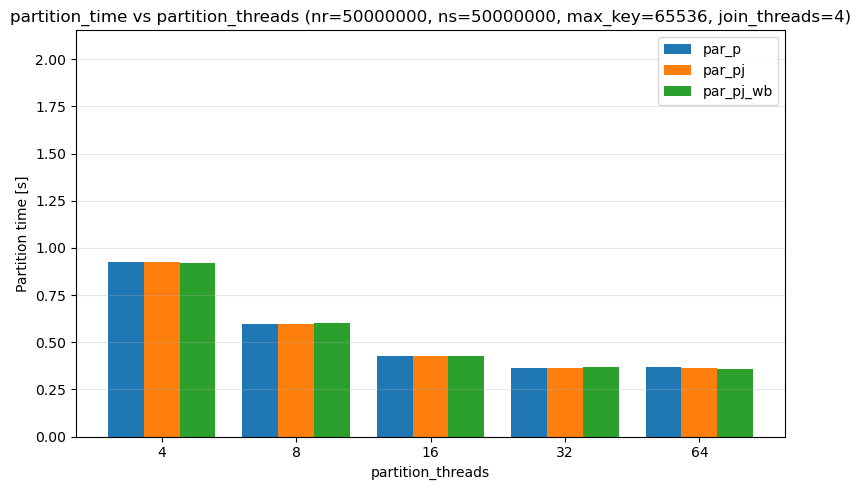

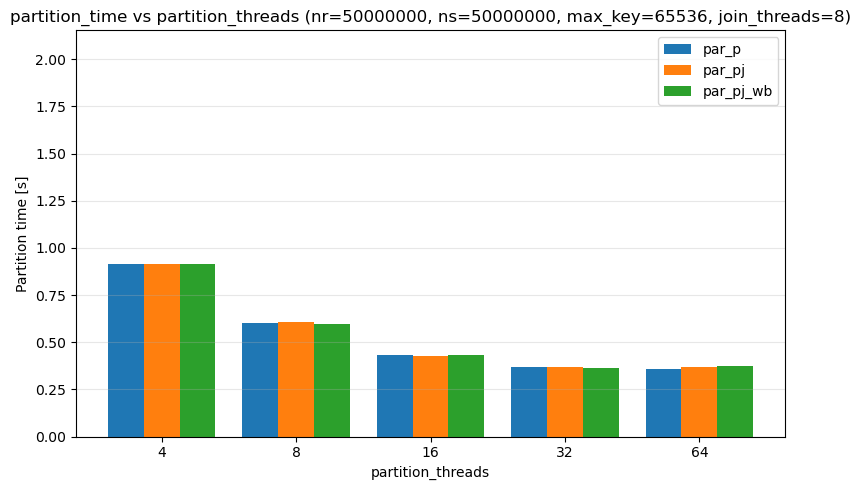

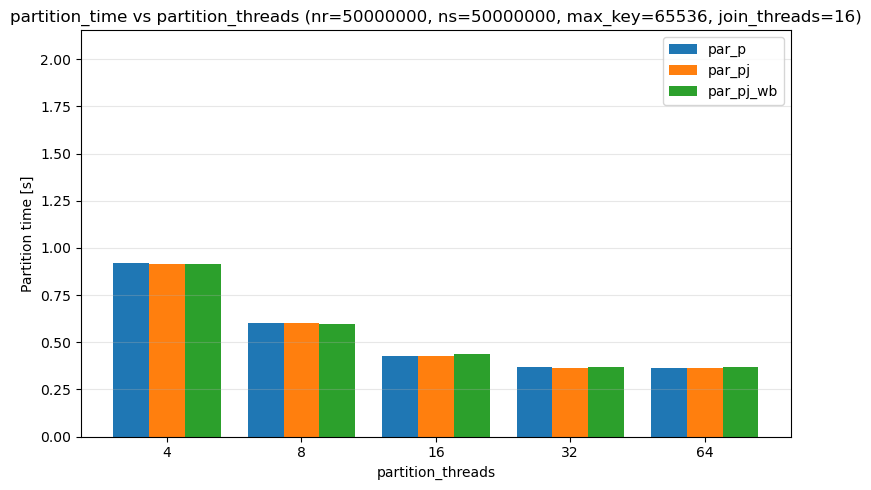

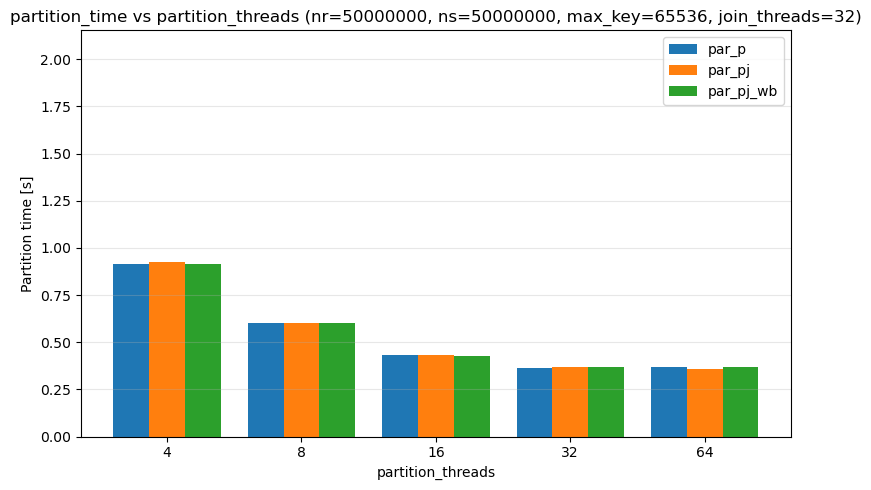

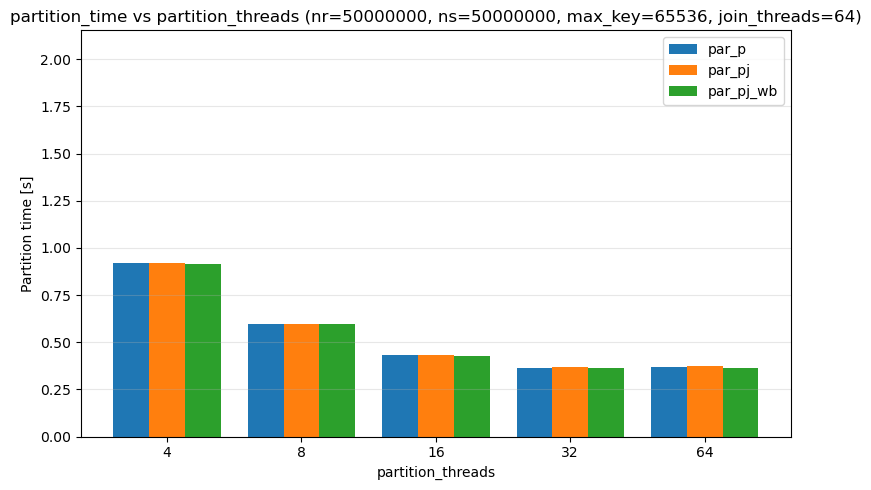

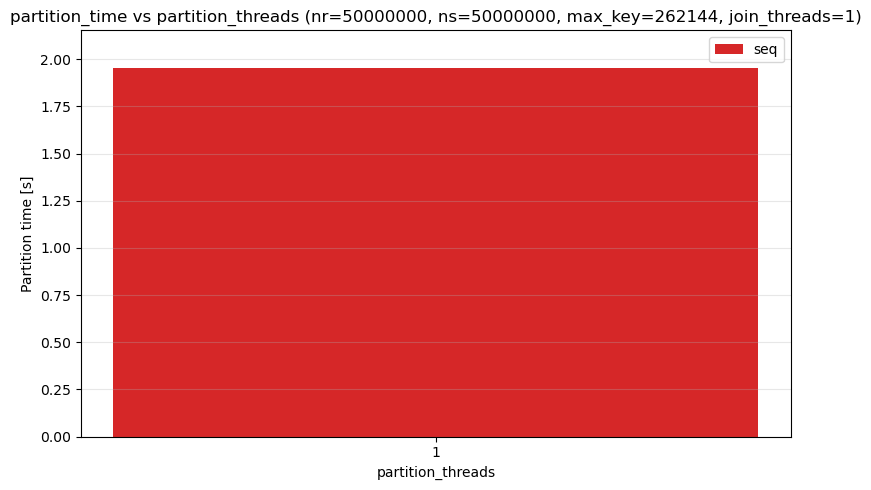

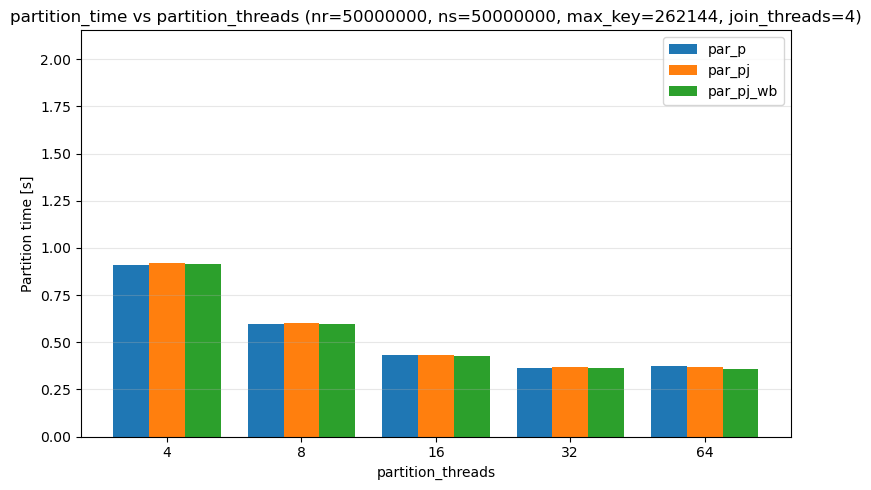

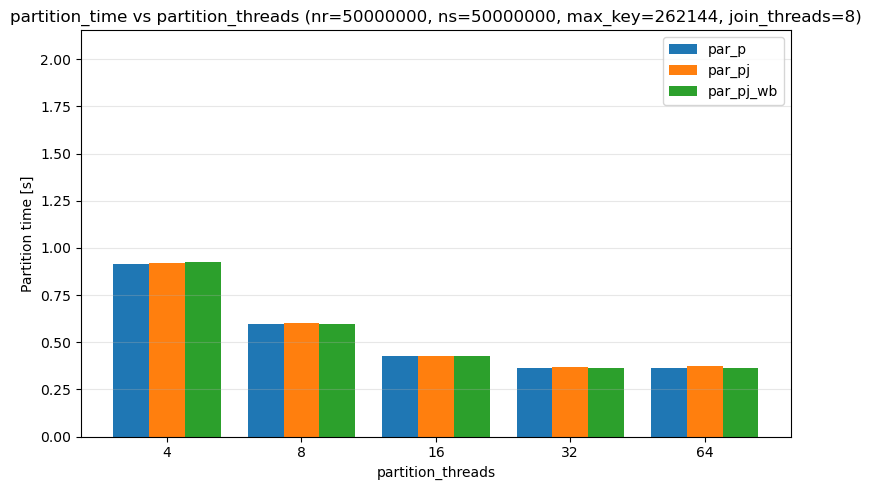

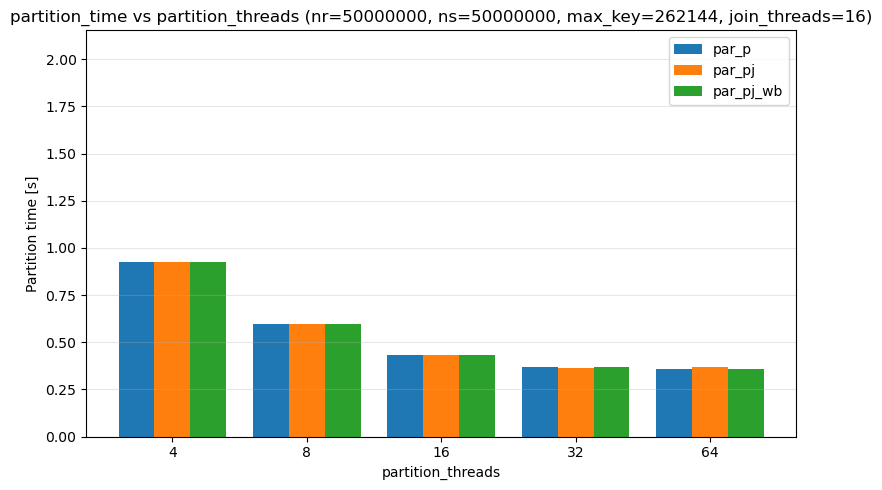

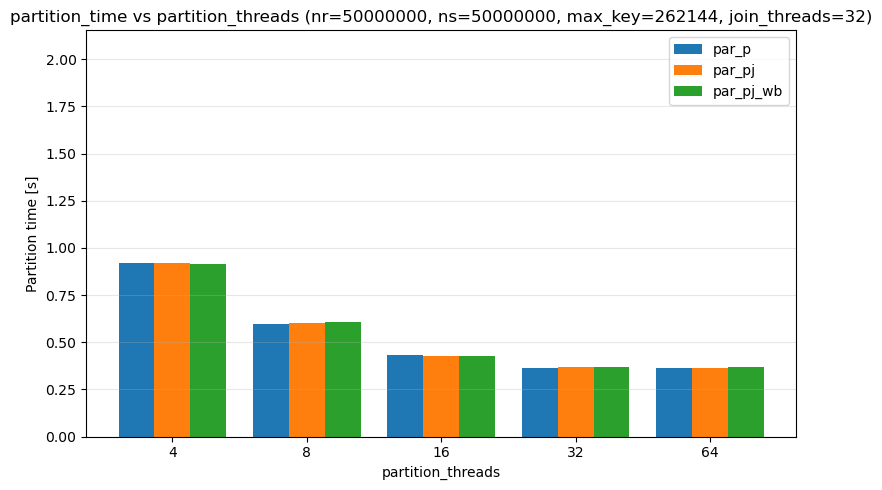

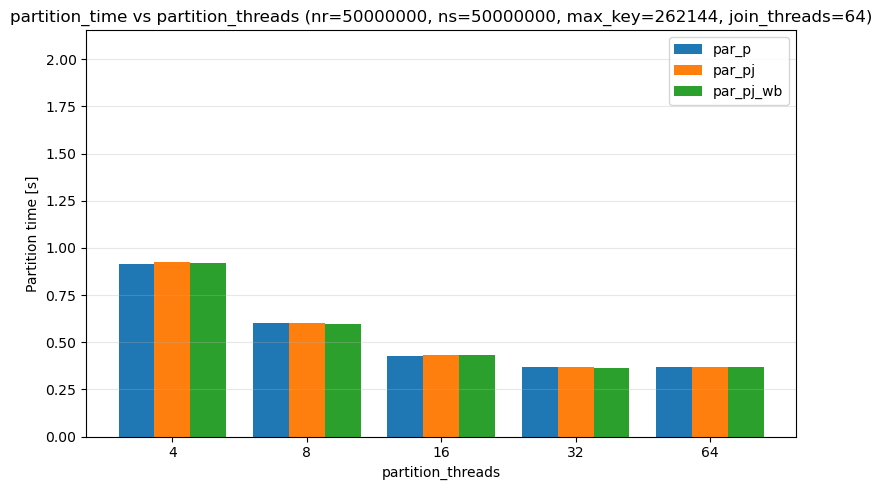

In [ ]:
if "partition_time" not in stable_avg_df.columns:
    print("partition_time column is missing")
else:
    global_partition_time_ymax = stable_avg_df["partition_time"].max()

    for (fixed_nr, fixed_ns, fixed_max_key, fixed_join_threads), subdf in stable_avg_df.groupby(
        ["nr", "ns", "max_key", "join_threads"]
    ):
        p_values = sorted(subdf["partition_threads"].dropna().unique())
        x_positions = list(range(len(p_values)))
        exec_types = sorted(subdf["exec_type"].dropna().unique())

        if not exec_types or not p_values:
            continue

        bar_width = 0.8 / len(exec_types)
        plt.figure(figsize=(8, 5))

        for idx, exec_type in enumerate(exec_types):
            g = subdf[subdf["exec_type"] == exec_type].sort_values("partition_threads")
            values_by_p = g.set_index("partition_threads")["partition_time"].to_dict()
            heights = [values_by_p.get(p, float("nan")) for p in p_values]
            offsets = [
                x + (idx - (len(exec_types) - 1) / 2) * bar_width
                for x in x_positions
            ]

            plt.bar(
                offsets,
                heights,
                width=bar_width,
                color=exec_type_colors.get(exec_type, "tab:gray"),
                label=exec_type,
            )

        if pd.notna(global_partition_time_ymax) and global_partition_time_ymax > 0:
            plt.ylim(0, global_partition_time_ymax * 1.1)

        plt.xticks(x_positions, [int(p) for p in p_values])
        plt.xlabel("threads")
        plt.ylabel("Partition time [s]")
        plt.title(
            f"partition_time vs threads (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)}, join_threads={int(fixed_join_threads)})"
        )
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Partition time standard deviation

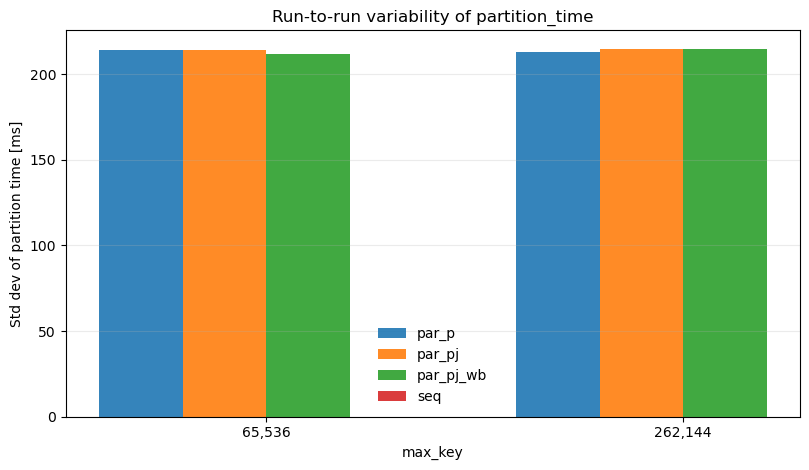

In [5]:
if "partition_time" not in df.columns:
    print("partition_time column is missing")
else:
    std_df = (
        df.groupby(["max_key", "exec_type"], as_index=False)
        .agg(std_partition_time=("partition_time", "std"))
    )
    std_df["std_ms"] = std_df["std_partition_time"] * 1e3

    max_key_values = sorted(std_df["max_key"].dropna().unique())
    exec_types = sorted(std_df["exec_type"].dropna().unique())

    x_positions = list(range(len(max_key_values)))
    bar_width = 0.8 / len(exec_types) if exec_types else 0.8

    plt.figure(figsize=(8.2, 4.8))
    for idx, exec_type in enumerate(exec_types):
        heights = []
        for max_key in max_key_values:
            sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
            heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]
        plt.bar(
            offsets,
            heights,
            width=bar_width,
            label=exec_type,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            alpha=0.9,
        )

    plt.xticks(x_positions, [f"{int(v):,}" for v in max_key_values])
    plt.xlabel("max_key")
    plt.ylabel("Std dev of partition time [ms]")
    plt.title("Run-to-run variability of partition_time")
    plt.grid(axis="y", alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Speedup (total throughput)

In [6]:
baseline_exec_type = "seq"

baseline_df = (
    stable_avg_df[stable_avg_df["exec_type"] == baseline_exec_type][
        ["nr", "ns", "max_key", "total_throughput"]
    ]
    .groupby(["nr", "ns", "max_key"], as_index=False)
    .agg(baseline_total_throughput=("total_throughput", "mean"))
)

if baseline_df.empty:
    raise ValueError("No seq baseline available for speedup computation")

speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["nr", "ns", "max_key"],
    how="left",
)

speedup_avg_df["speedup_total_throughput"] = (
    speedup_avg_df["total_throughput"] / speedup_avg_df["baseline_total_throughput"]
)
speedup_avg_df.loc[speedup_avg_df["baseline_total_throughput"] <= 0, "speedup_total_throughput"] = float("nan")

speedup_avg_df.head(10)


,exec_type,nr,ns,max_key,partition_threads,join_threads,checksum1,checksum2,join_count,partition_time,join_time,time_sec,partition_throughput,join_throughput,total_throughput,baseline_total_throughput,speedup_total_throughput
0,par_p,50000000,50000000,65536,4,4,15384239832666499847,2938791386226452392,38147013639,0.923281,1.728507,2.654026,1.083094e+08,5.785339e+07,3.767861e+07,2.710291e+07,1.390205
1,par_p,50000000,50000000,65536,4,8,15384239832666499847,2938791386226452392,38147013639,0.917350,1.729064,2.648659,1.090096e+08,5.783478e+07,3.775495e+07,2.710291e+07,1.393022
2,par_p,50000000,50000000,65536,4,16,15384239832666499847,2938791386226452392,38147013639,0.917957,1.729737,2.649956,1.089376e+08,5.781227e+07,3.773648e+07,2.710291e+07,1.392340
3,par_p,50000000,50000000,65536,4,32,15384239832666499847,2938791386226452392,38147013639,0.913989,1.764192,2.680497,1.094105e+08,5.668316e+07,3.730651e+07,2.710291e+07,1.376476
4,par_p,50000000,50000000,65536,4,64,15384239832666499847,2938791386226452392,38147013639,0.920059,1.727600,2.649955,1.086887e+08,5.788377e+07,3.773650e+07,2.710291e+07,1.392341
5,par_p,50000000,50000000,65536,8,4,15384239832666499847,2938791386226452392,38147013639,0.598678,1.729037,2.330017,1.670346e+08,5.783565e+07,4.291813e+07,2.710291e+07,1.583525
6,par_p,50000000,50000000,65536,8,8,15384239832666499847,2938791386226452392,38147013639,0.602994,1.727621,2.332965,1.658391e+08,5.788306e+07,4.286391e+07,2.710291e+07,1.581524
7,par_p,50000000,50000000,65536,8,16,15384239832666499847,2938791386226452392,38147013639,0.602841,1.728109,2.333253,1.658812e+08,5.786672e+07,4.285862e+07,2.710291e+07,1.581329
8,par_p,50000000,50000000,65536,8,32,15384239832666499847,2938791386226452392,38147013639,0.601802,1.725065,2.329143,1.661675e+08,5.796884e+07,4.293425e+07,2.710291e+07,1.584119
9,par_p,50000000,50000000,65536,8,64,15384239832666499847,2938791386226452392,38147013639,0.596932,1.726995,2.326216,1.675232e+08,5.790403e+07,4.298827e+07,2.710291e+07,1.586113


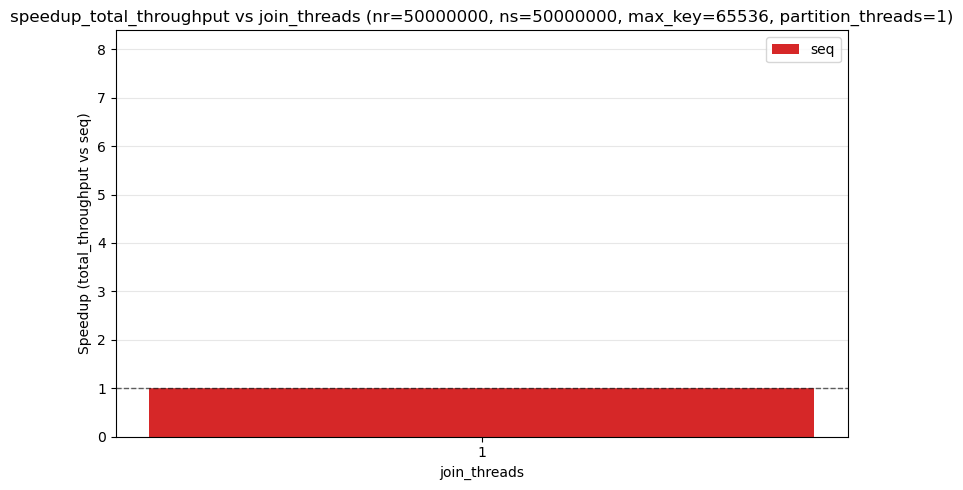

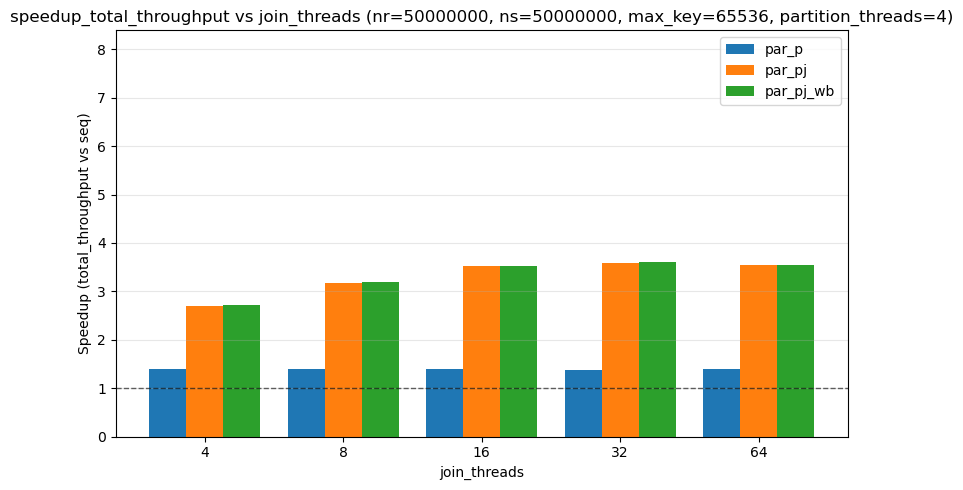

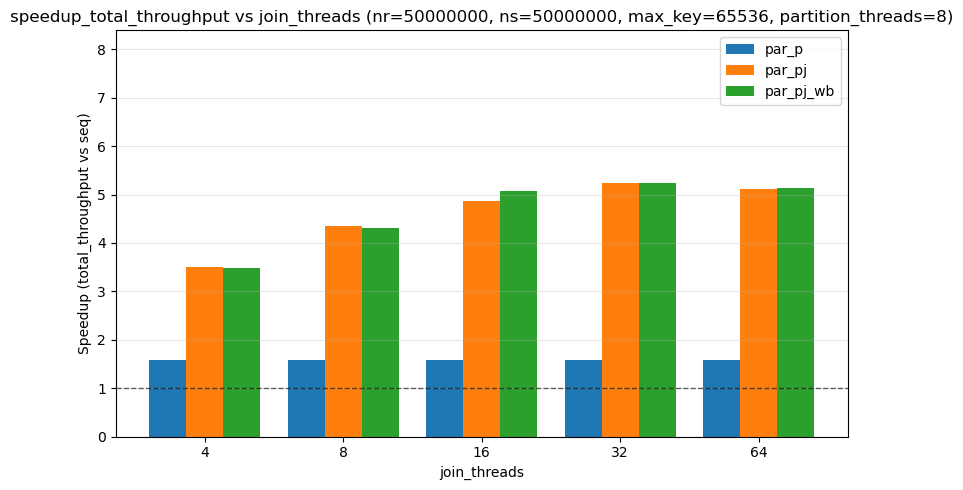

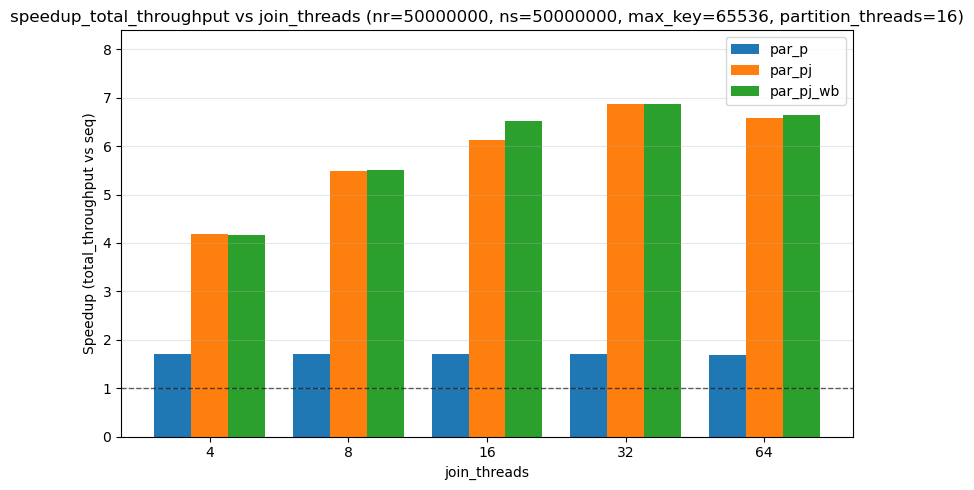

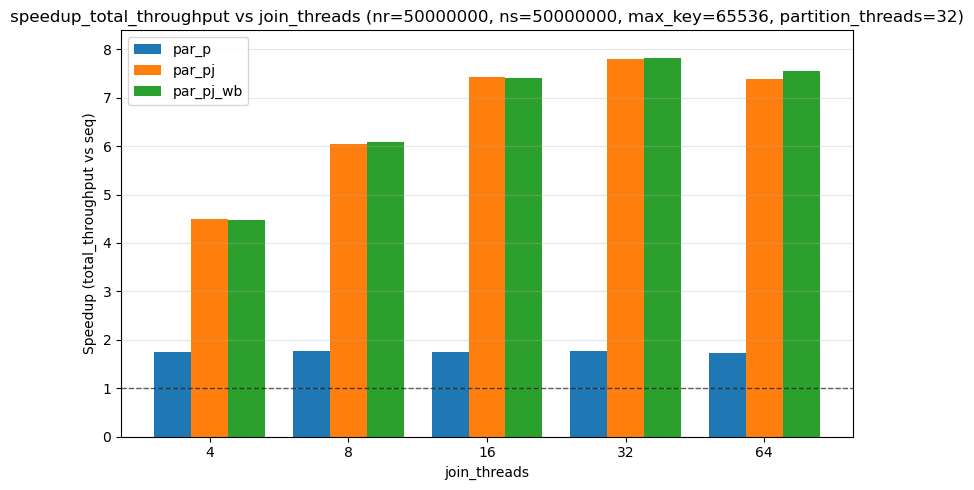

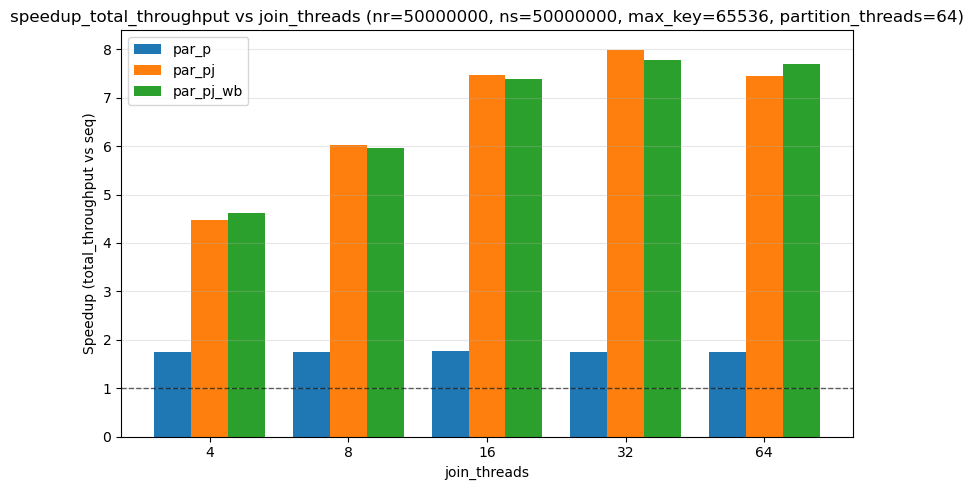

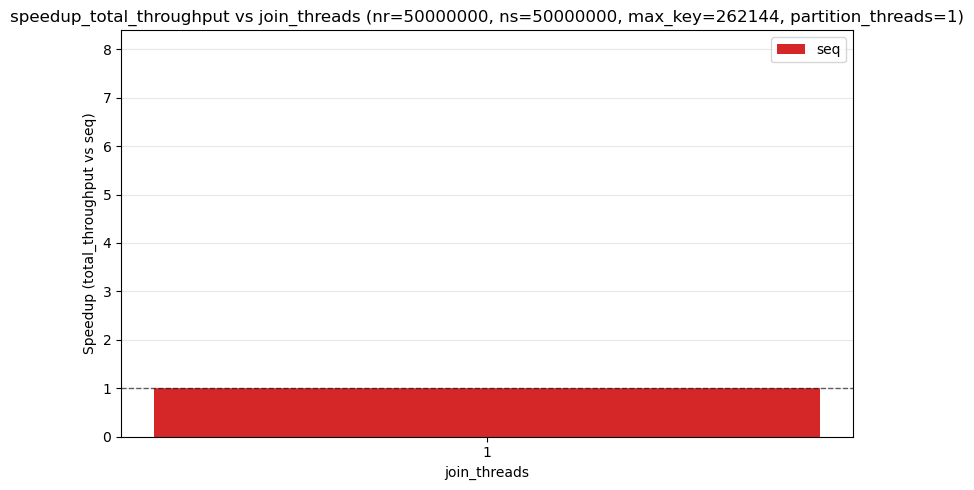

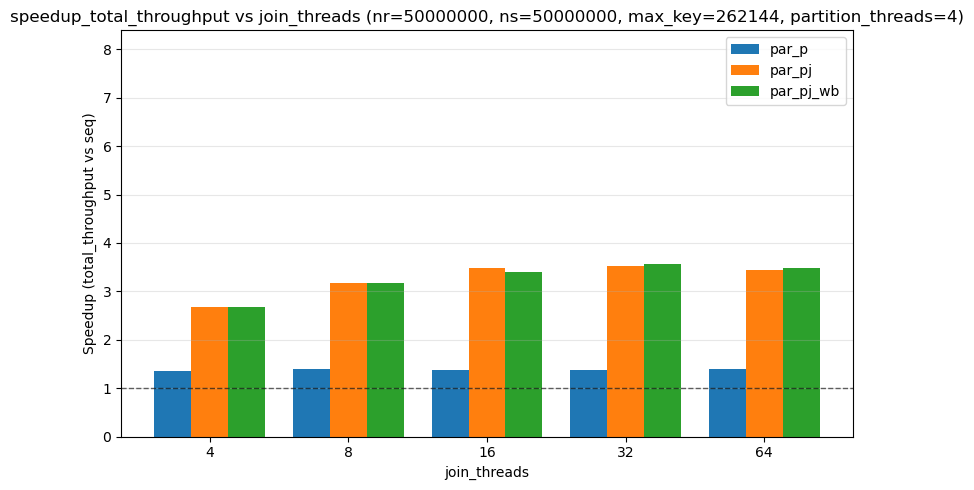

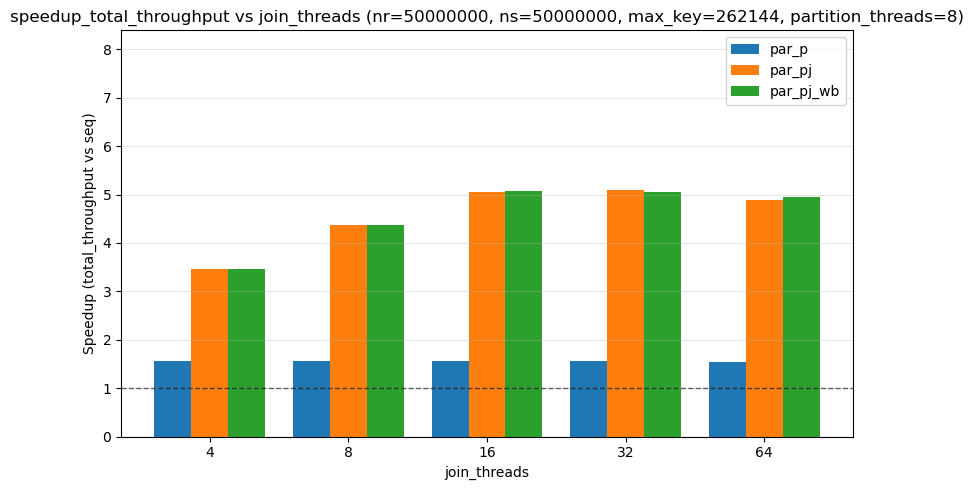

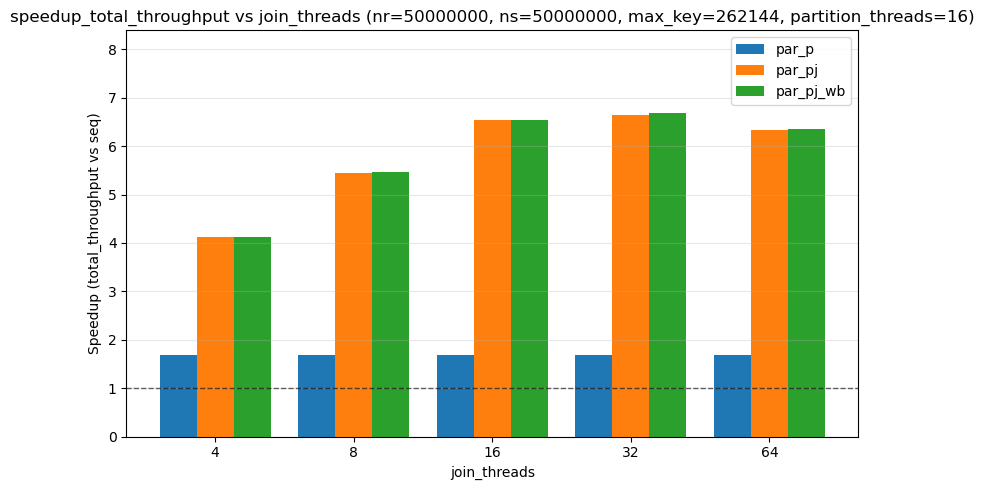

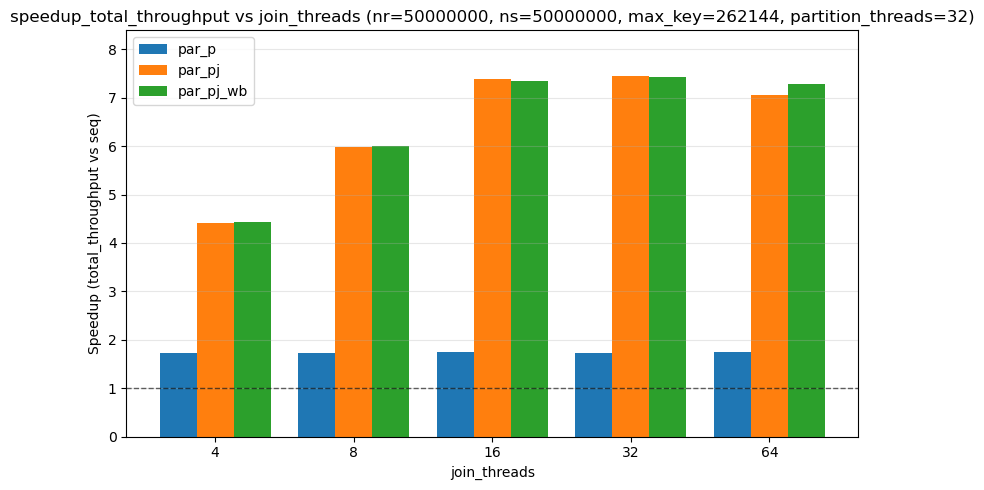

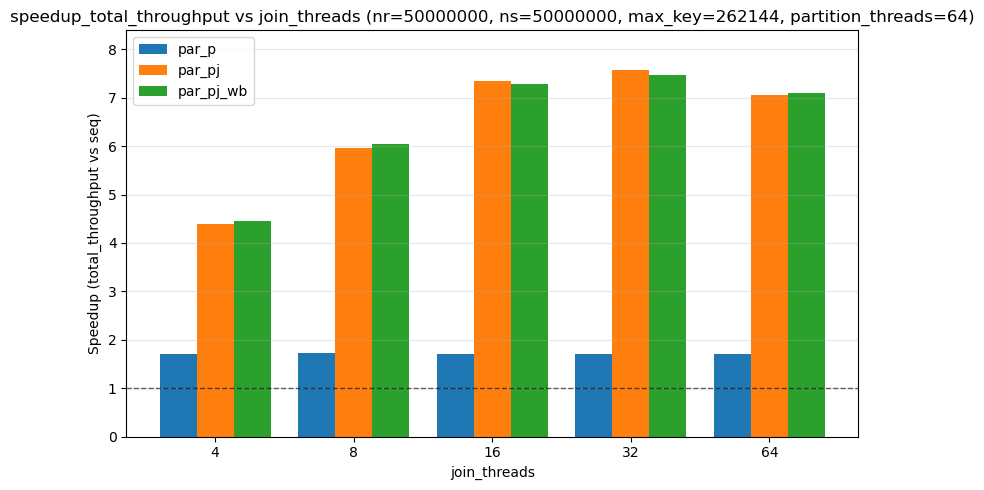

In [ ]:
global_speedup_ymax = speedup_avg_df["speedup_total_throughput"].max()

for (fixed_nr, fixed_ns, fixed_max_key, fixed_part_threads), subdf in speedup_avg_df.groupby(
    ["nr", "ns", "max_key", "partition_threads"]
):
    j_values = sorted(subdf["join_threads"].dropna().unique())
    x_positions = list(range(len(j_values)))
    exec_types = sorted(subdf["exec_type"].dropna().unique())

    if not exec_types or not j_values:
        continue

    bar_width = 0.8 / len(exec_types)

    plt.figure(figsize=(8, 5))
    for idx, exec_type in enumerate(exec_types):
        g = subdf[subdf["exec_type"] == exec_type].sort_values("join_threads")
        values_by_j = g.set_index("join_threads")["speedup_total_throughput"].to_dict()
        heights = [values_by_j.get(j, float("nan")) for j in j_values]
        offsets = [
            x + (idx - (len(exec_types) - 1) / 2) * bar_width
            for x in x_positions
        ]

        plt.bar(
            offsets,
            heights,
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    if pd.notna(global_speedup_ymax) and global_speedup_ymax > 0:
        plt.ylim(0, global_speedup_ymax * 1.05)

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(x_positions, [int(j) for j in j_values])
    plt.xlabel("threads")
    plt.ylabel("Speedup")
    plt.title(
        f"speedup_total_throughput vs join_threads (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)}, partition_threads={int(fixed_part_threads)})"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Throughput

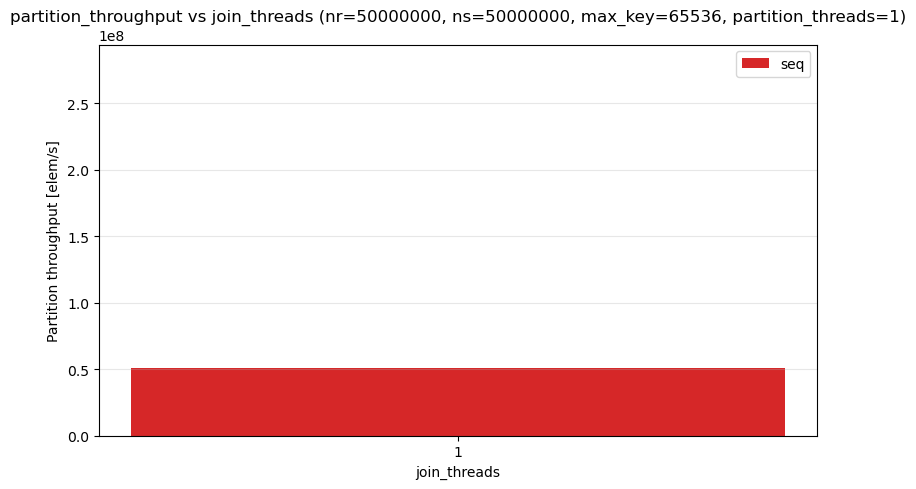

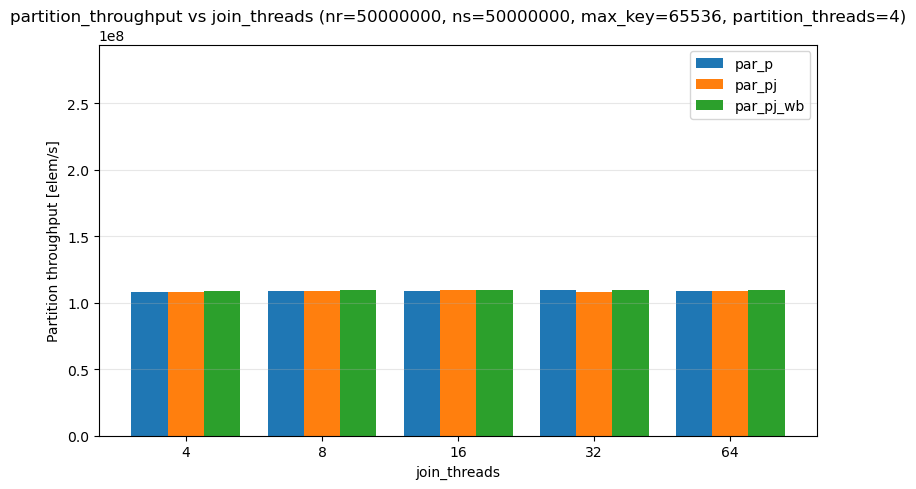

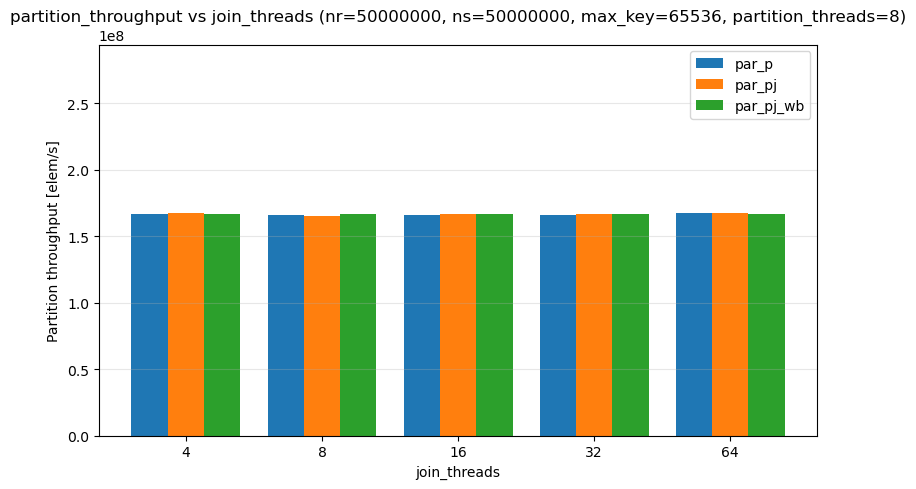

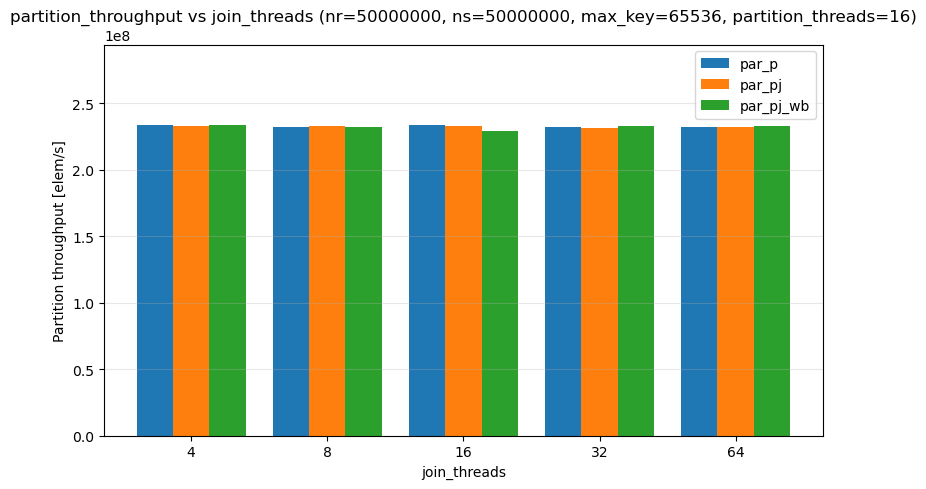

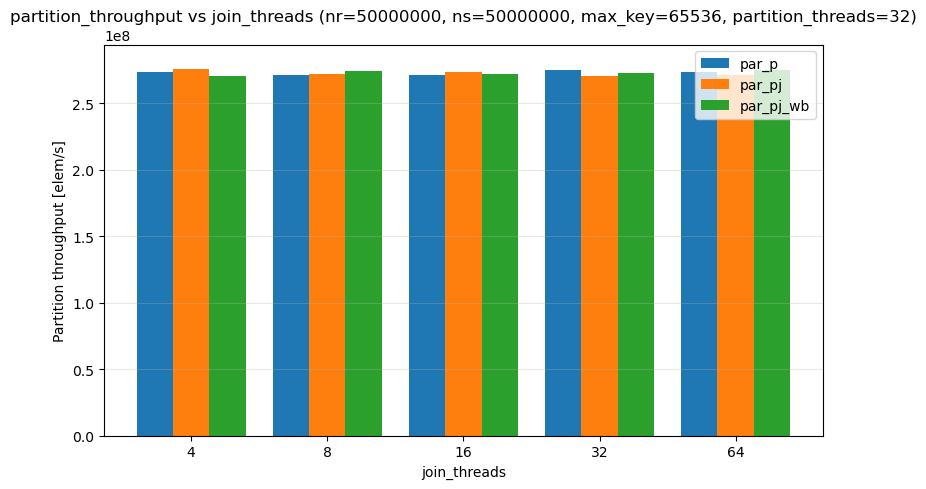

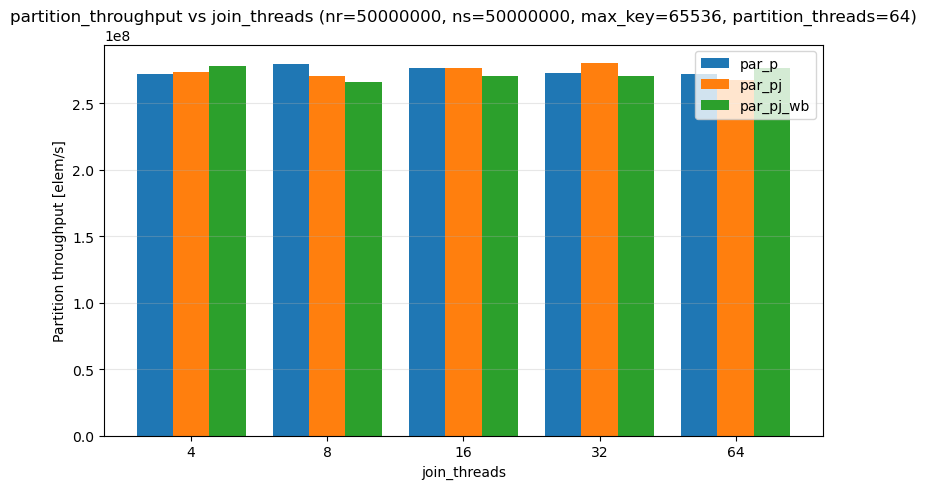

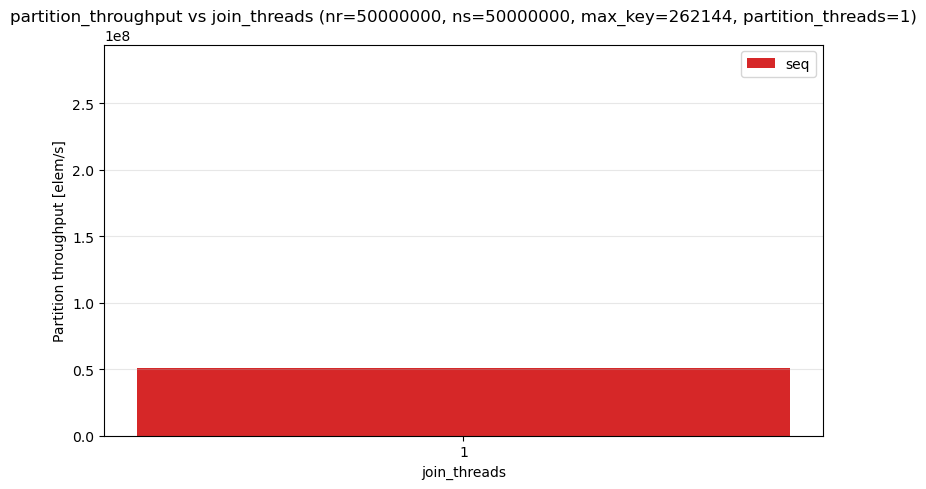

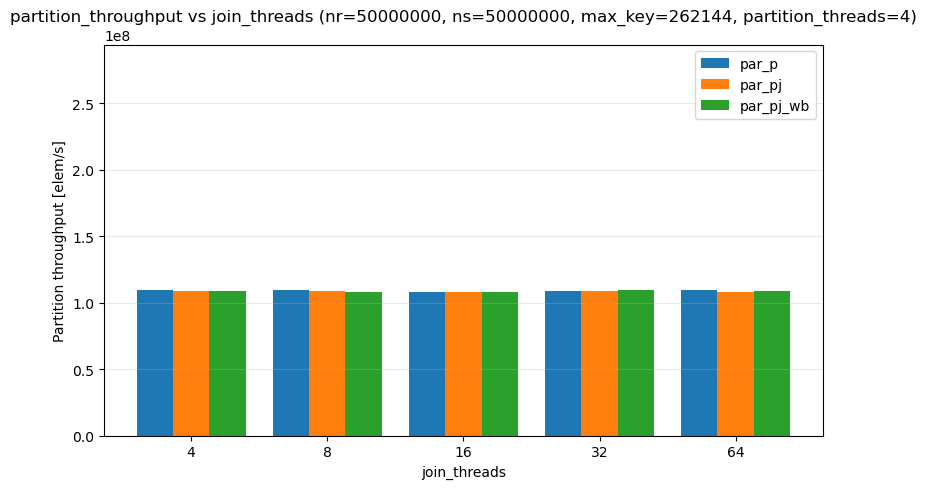

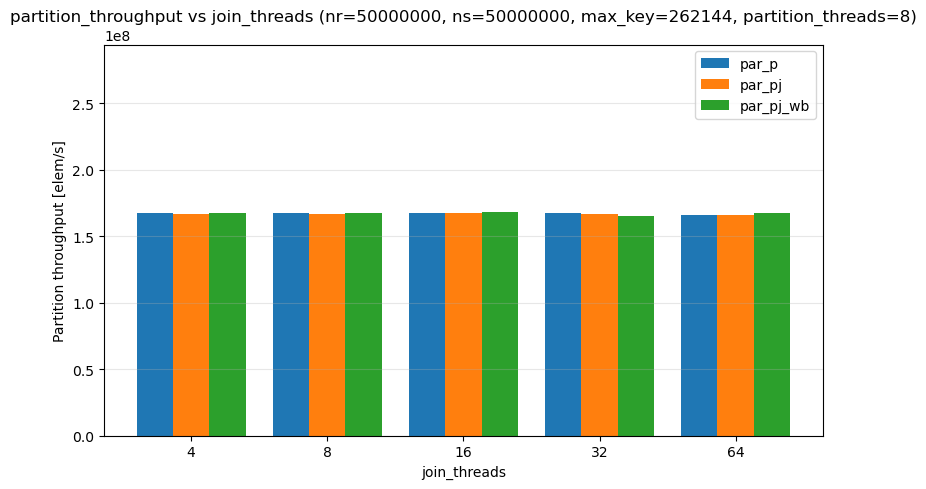

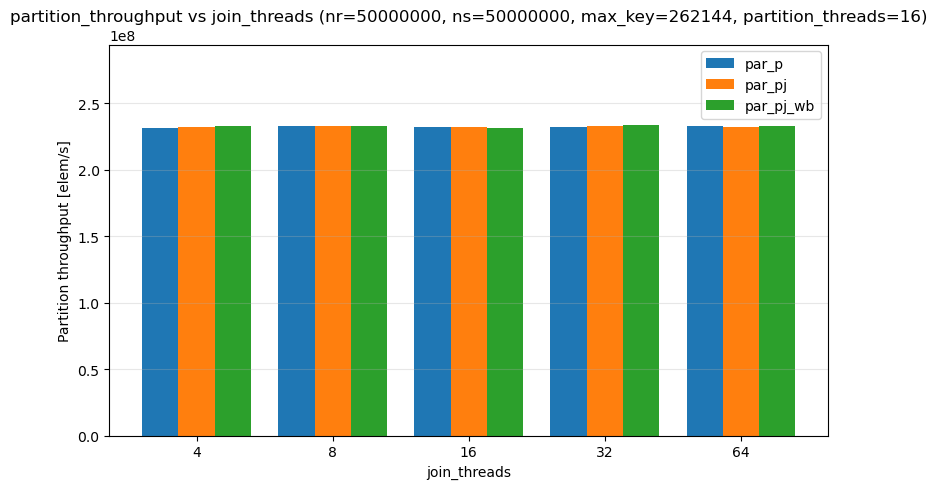

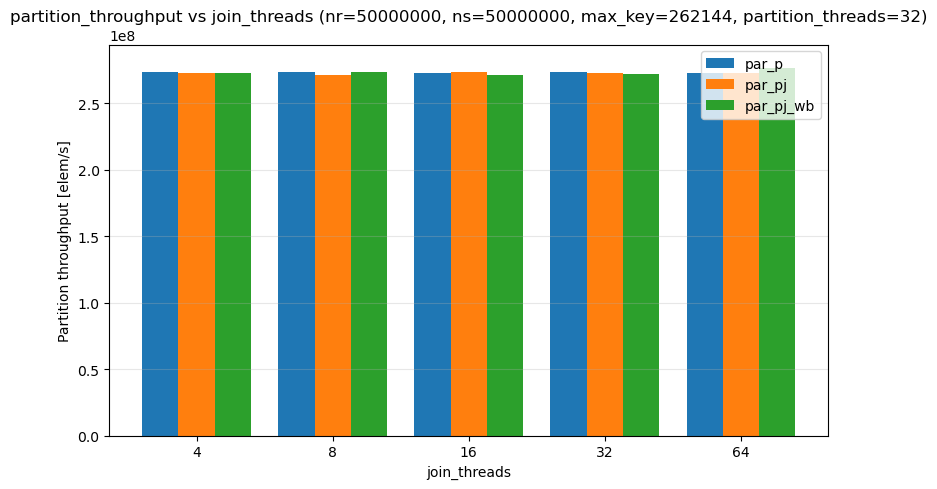

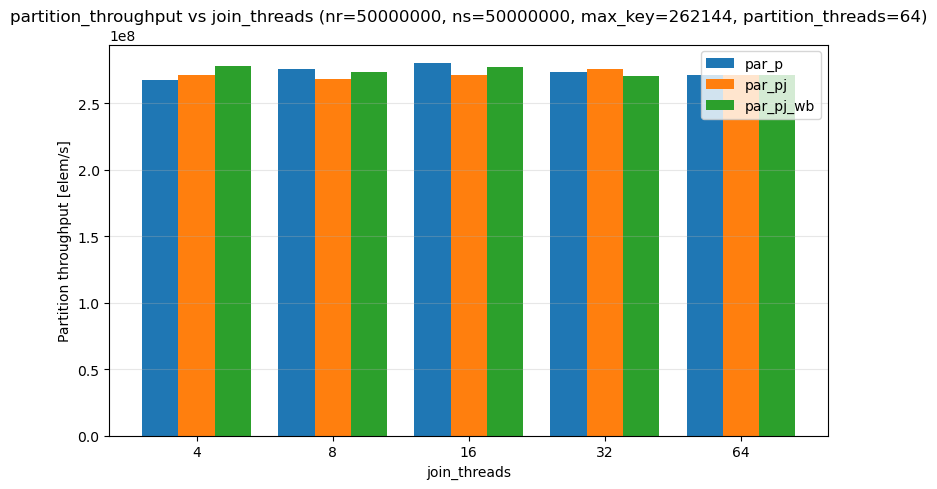

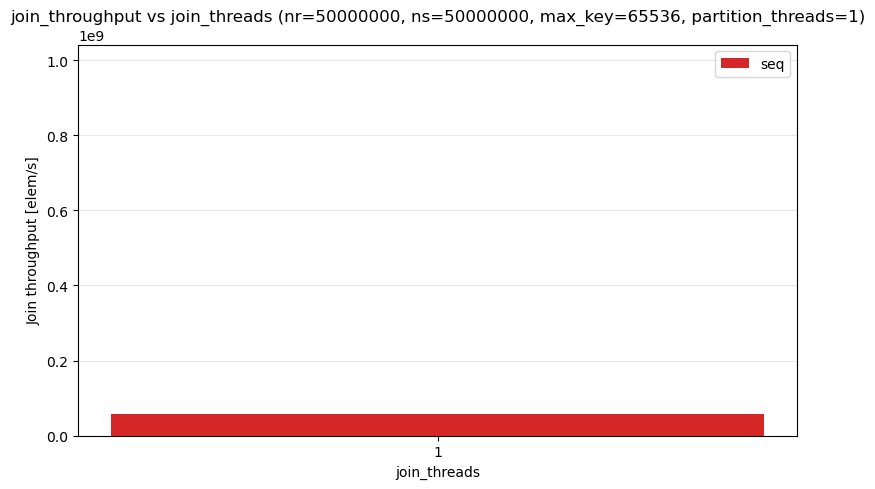

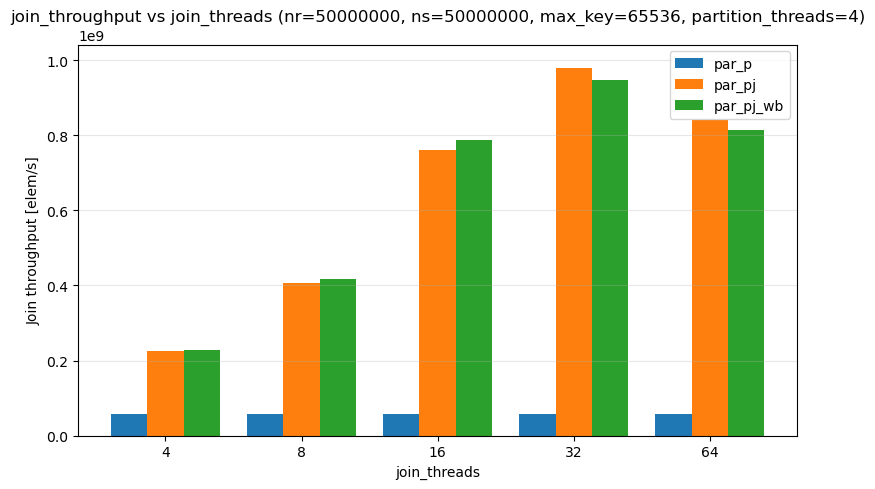

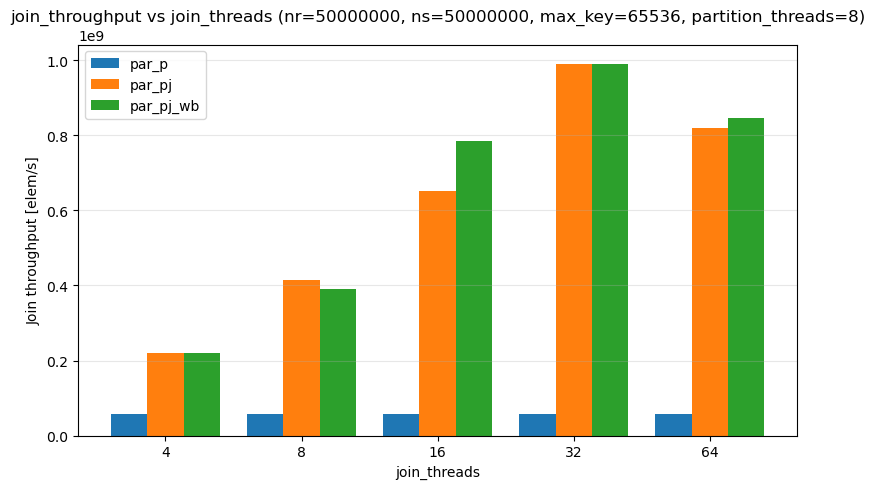

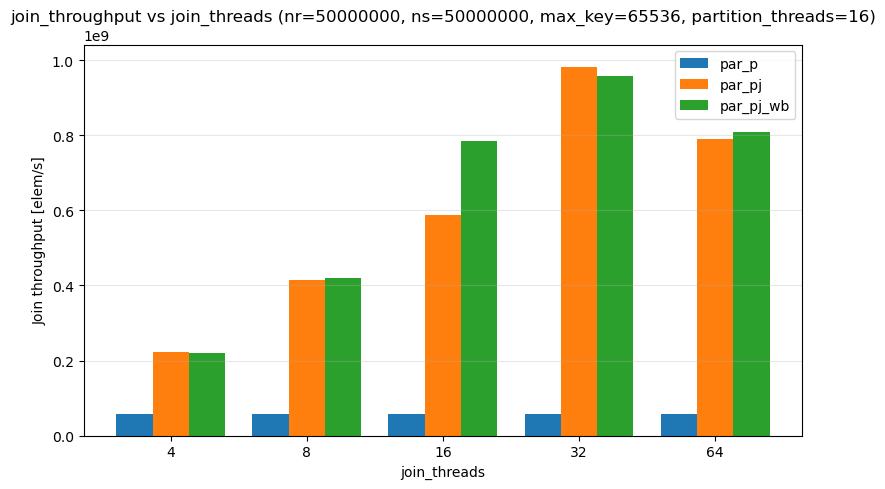

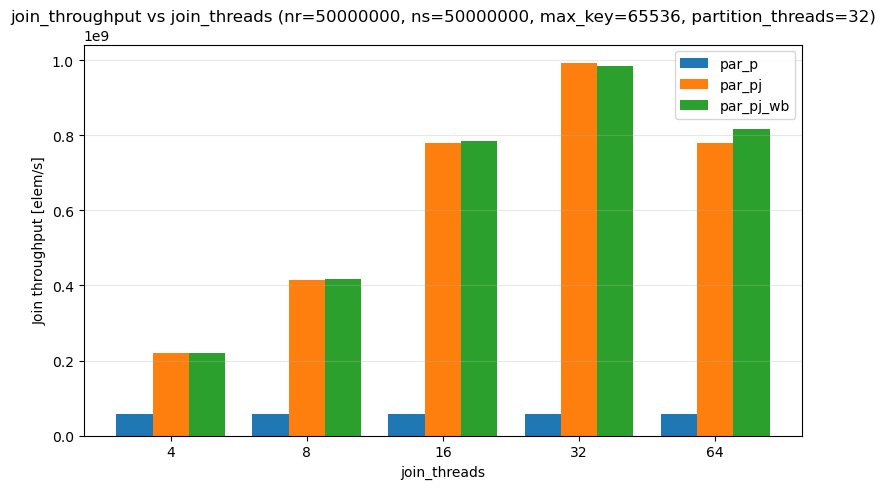

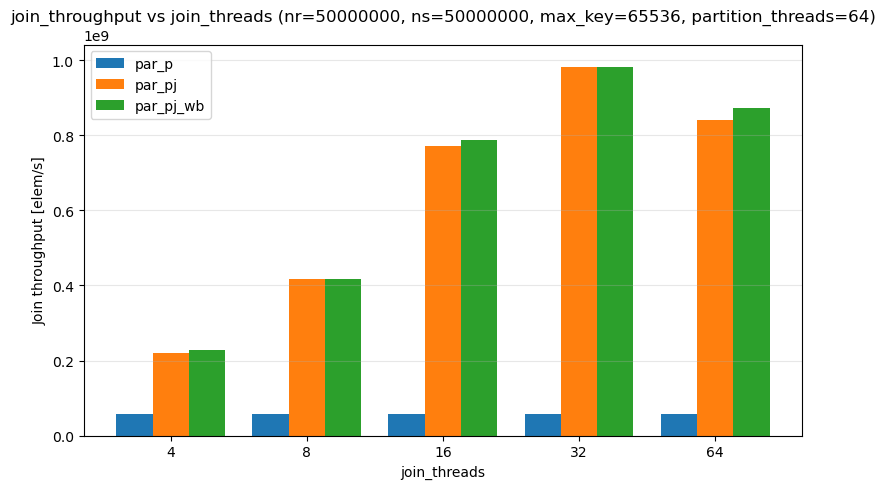

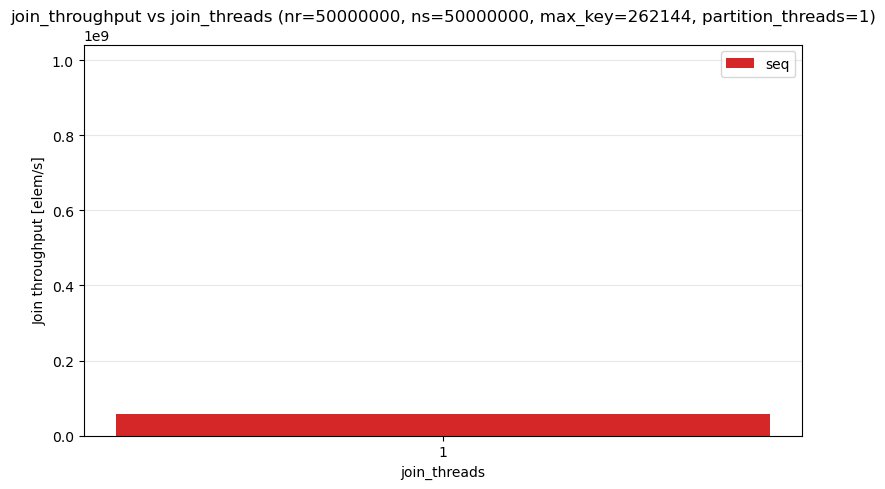

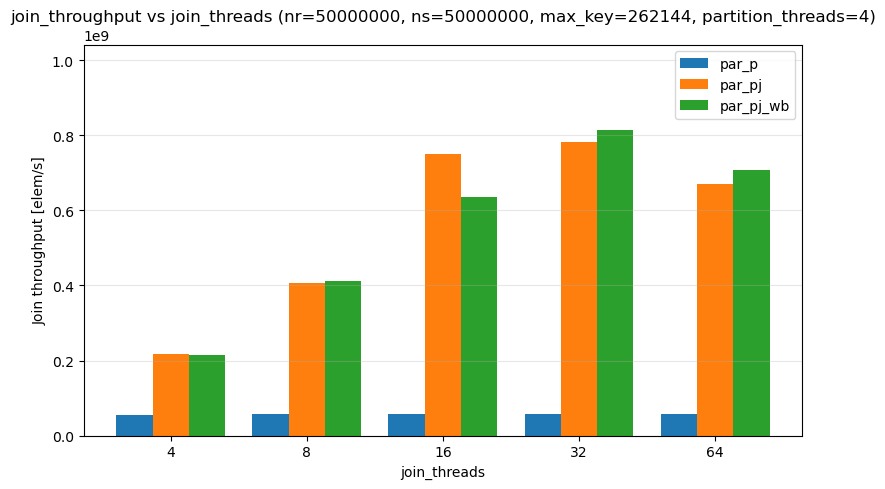

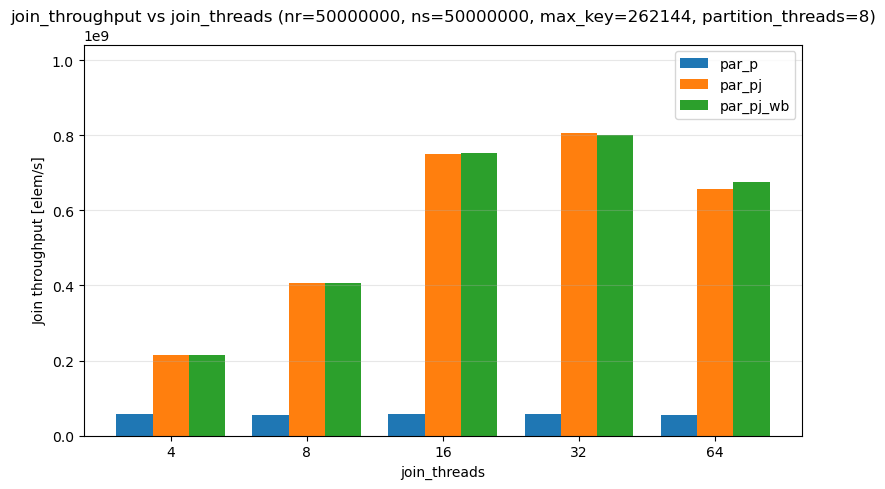

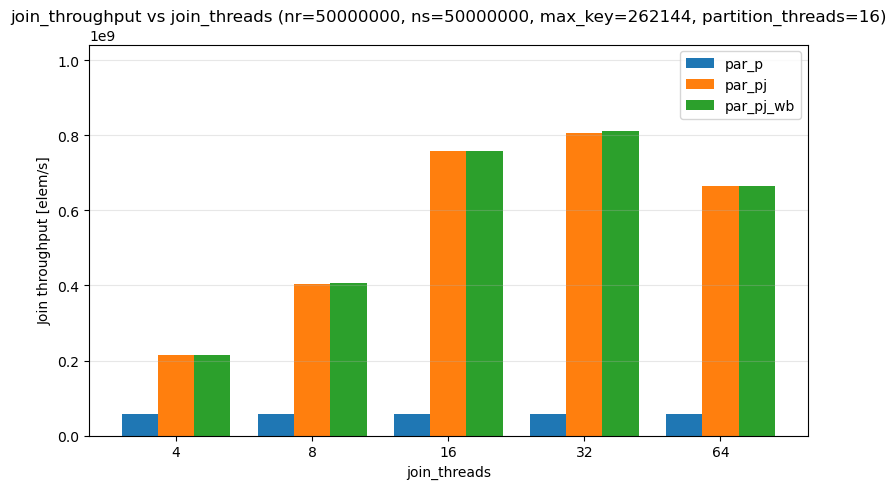

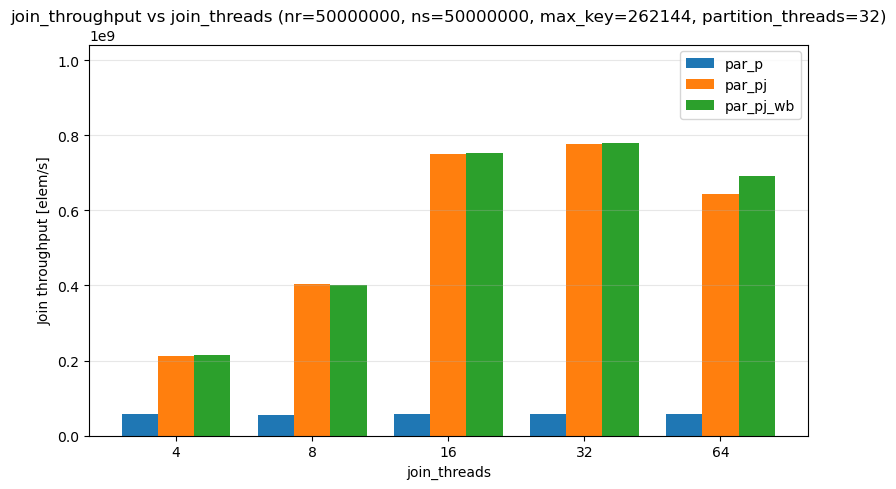

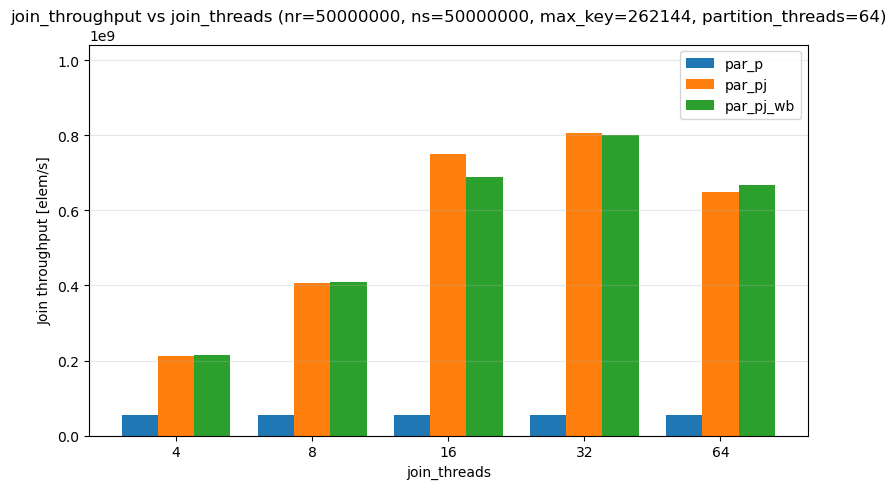

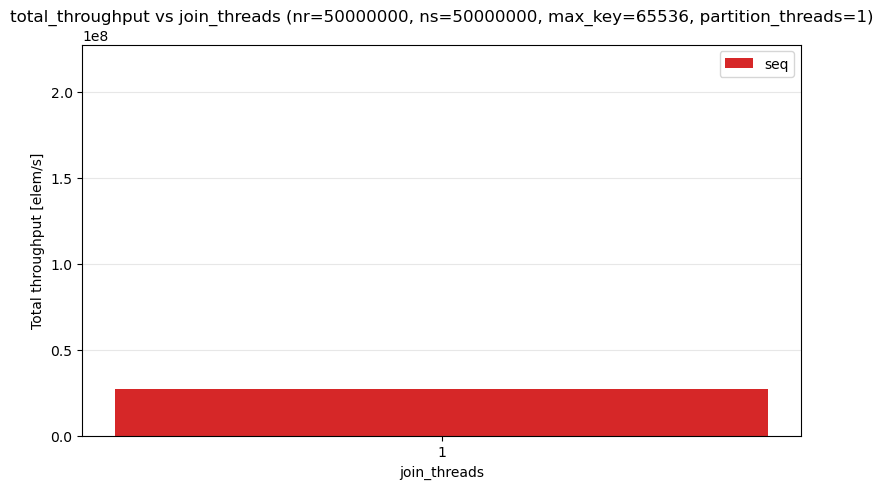

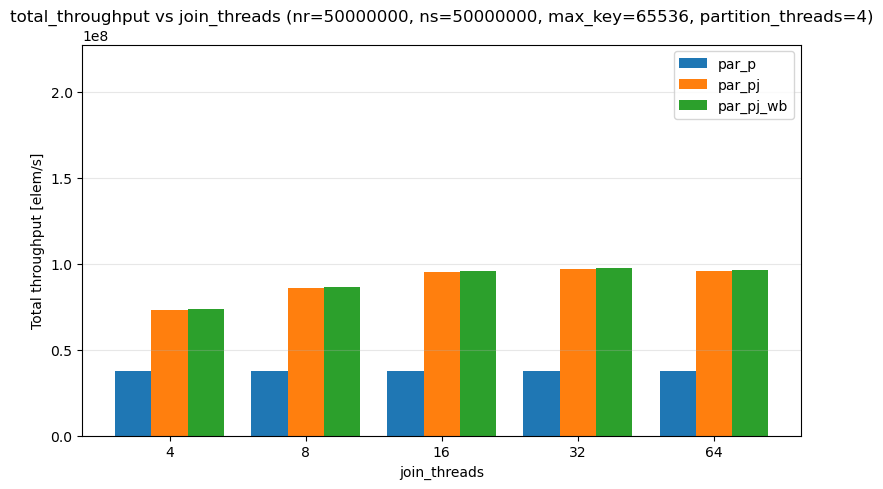

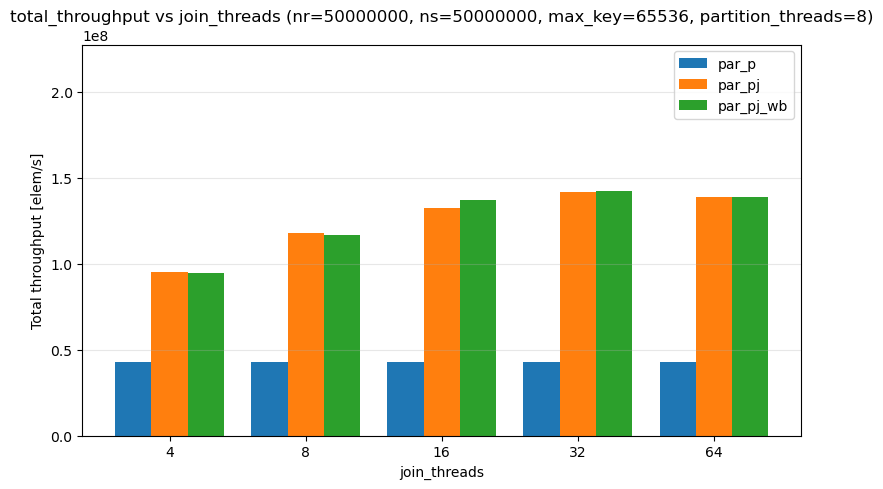

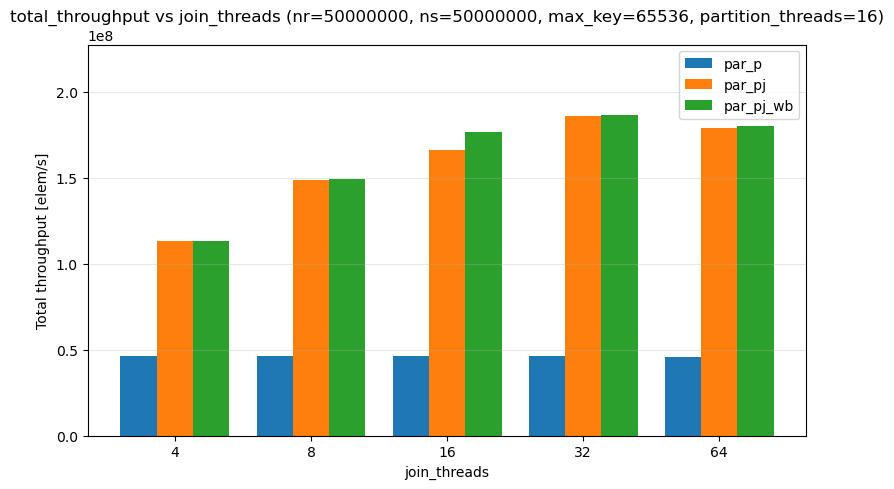

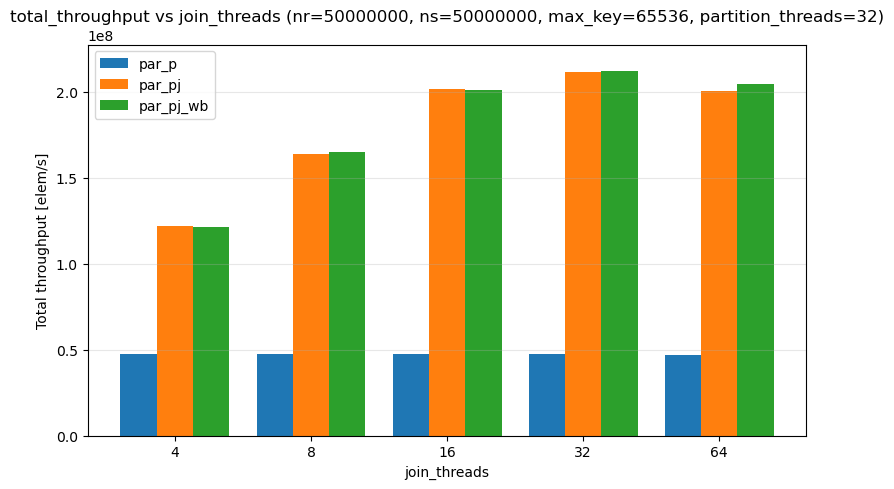

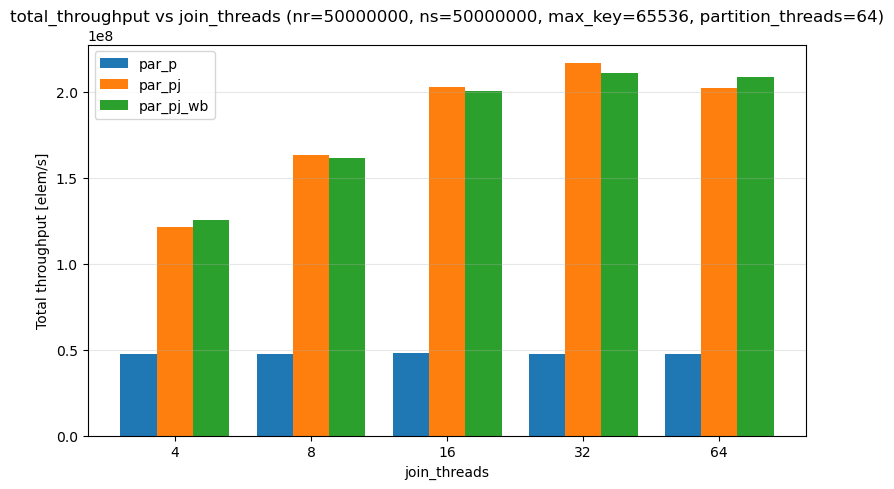

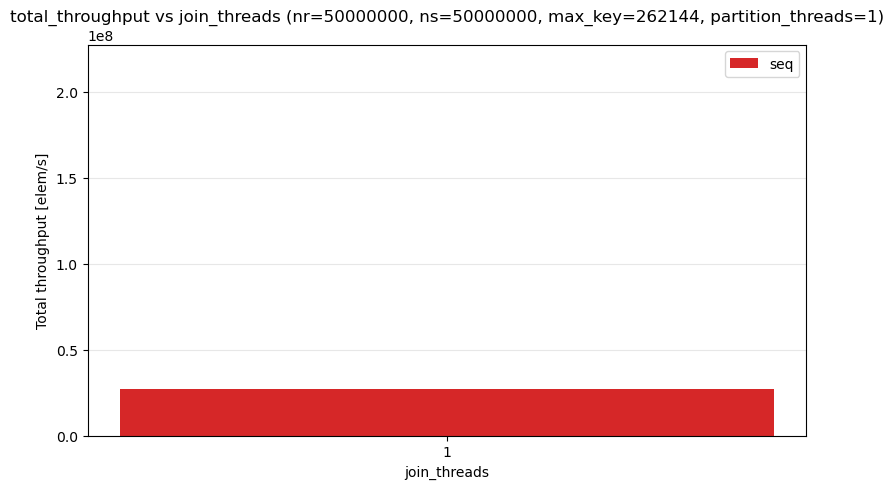

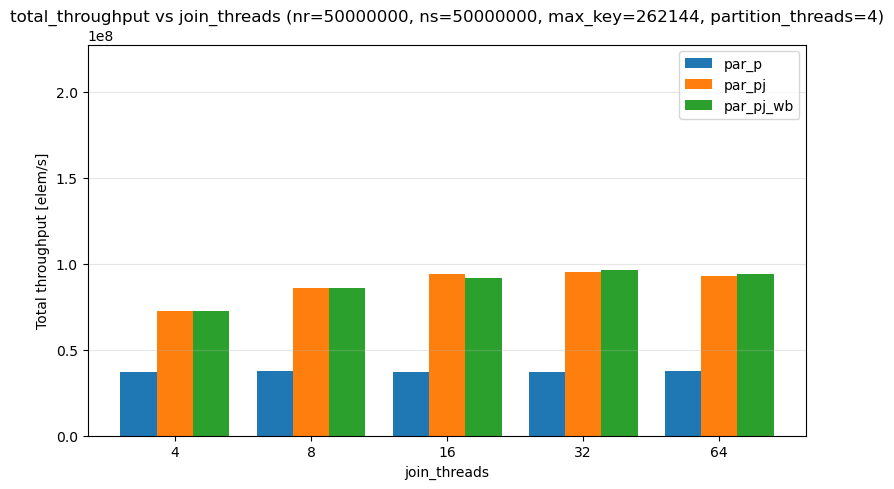

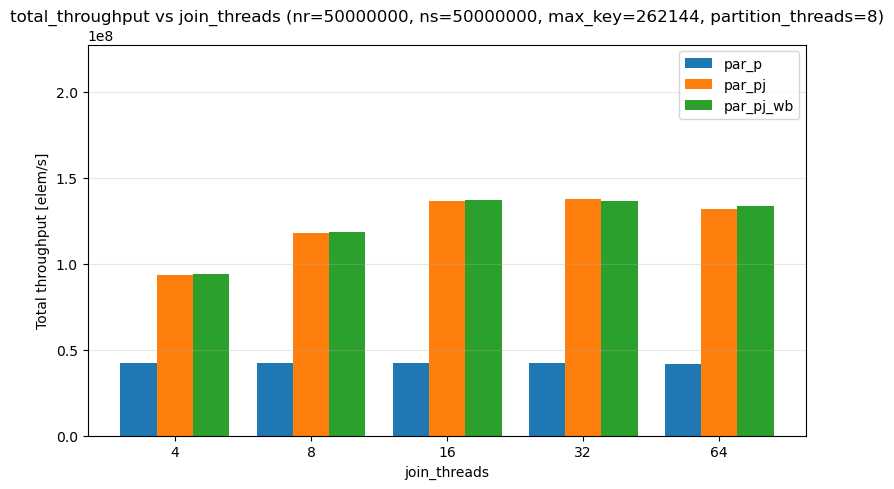

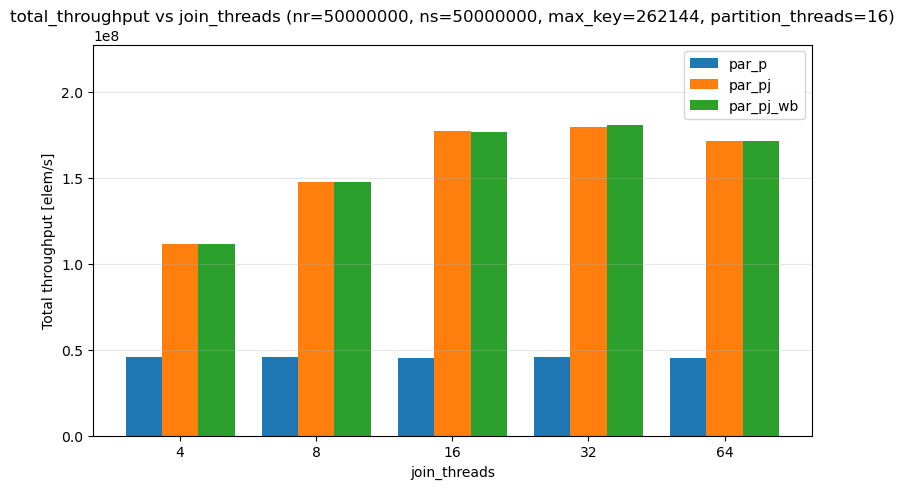

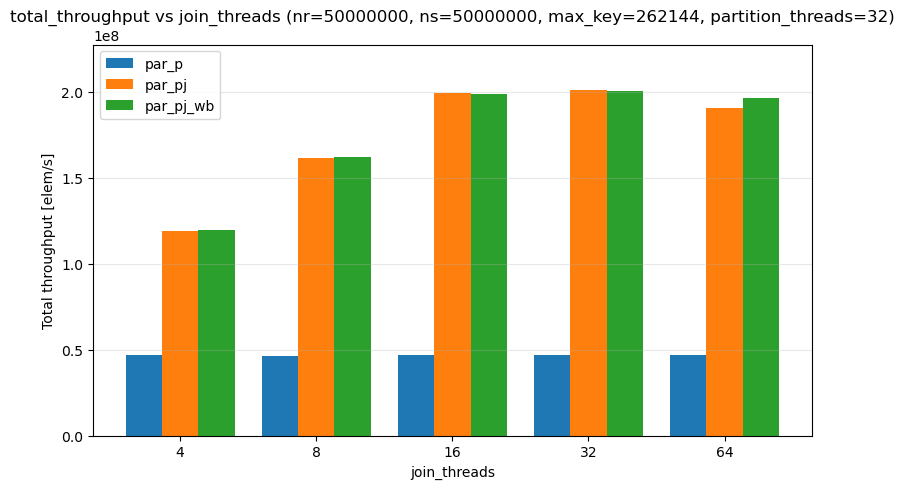

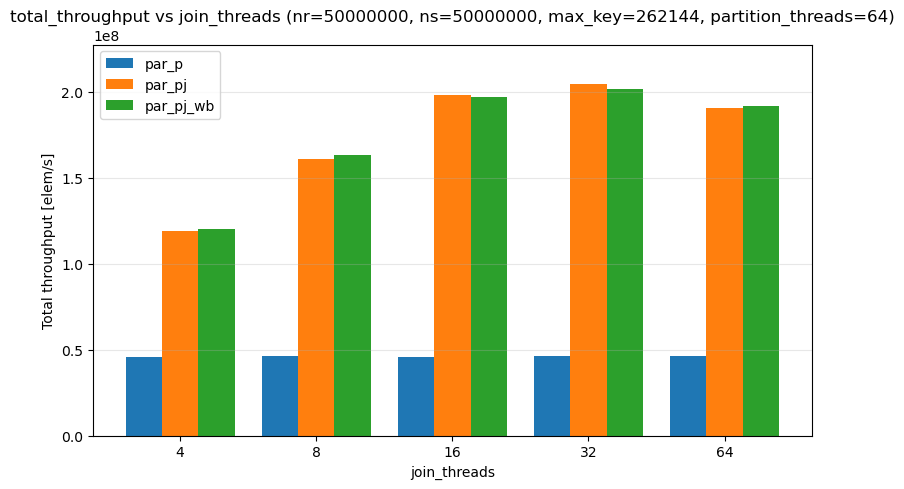

In [8]:
throughput_metrics = [
    ("partition_throughput", "Partition throughput [elem/s]"),
    ("join_throughput", "Join throughput [elem/s]"),
    ("total_throughput", "Total throughput [elem/s]"),
]

for metric_col, ylabel in throughput_metrics:
    if metric_col not in stable_avg_df.columns:
        continue

    global_metric_ymax = stable_avg_df[metric_col].max()

    for (fixed_nr, fixed_ns, fixed_max_key, fixed_part_threads), subdf in stable_avg_df.groupby(
        ["nr", "ns", "max_key", "partition_threads"]
    ):
        j_values = sorted(subdf["join_threads"].dropna().unique())
        x_positions = list(range(len(j_values)))
        exec_types = sorted(subdf["exec_type"].dropna().unique())

        if not exec_types or not j_values:
            continue

        bar_width = 0.8 / len(exec_types)
        plt.figure(figsize=(8, 5))

        for idx, exec_type in enumerate(exec_types):
            g = subdf[subdf["exec_type"] == exec_type].sort_values("join_threads")
            values_by_j = g.set_index("join_threads")[metric_col].to_dict()
            heights = [values_by_j.get(j, float("nan")) for j in j_values]
            offsets = [
                x + (idx - (len(exec_types) - 1) / 2) * bar_width
                for x in x_positions
            ]

            plt.bar(
                offsets,
                heights,
                width=bar_width,
                color=exec_type_colors.get(exec_type, "tab:gray"),
                label=exec_type,
            )

        if pd.notna(global_metric_ymax) and global_metric_ymax > 0:
            plt.ylim(0, global_metric_ymax * 1.05)

        plt.xticks(x_positions, [int(j) for j in j_values])
        plt.xlabel("join_threads")
        plt.ylabel(ylabel)
        plt.title(
            f"{metric_col} vs join_threads (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)}, partition_threads={int(fixed_part_threads)})"
        )
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Throughput over N

In [9]:
if df["nr"].nunique() <= 1:
    print("Only one nr value is present in the current CSVs; skipping throughput-over-N plots.")
else:
    throughput_metrics = [
        ("partition_throughput", "Partition throughput [elem/s]"),
        ("join_throughput", "Join throughput [elem/s]"),
        ("total_throughput", "Total throughput [elem/s]"),
    ]

    for metric_col, ylabel in throughput_metrics:
        if metric_col not in stable_avg_df.columns:
            continue

        best_over_n_df = (
            stable_avg_df.groupby(["exec_type", "nr", "max_key"], as_index=False)
            .agg(best_metric=(metric_col, "max"))
            .sort_values(["max_key", "nr", "exec_type"])
        )

        global_metric_ymax = best_over_n_df["best_metric"].max()

        for fixed_max_key, subdf in best_over_n_df.groupby("max_key"):
            n_values = sorted(subdf["nr"].dropna().unique())
            x_positions = list(range(len(n_values)))
            exec_types = sorted(subdf["exec_type"].dropna().unique())

            if not exec_types or not n_values:
                continue

            bar_width = 0.8 / len(exec_types)
            plt.figure(figsize=(8, 5))

            for idx, exec_type in enumerate(exec_types):
                g = subdf[subdf["exec_type"] == exec_type].sort_values("nr")
                values_by_n = g.set_index("nr")["best_metric"].to_dict()
                heights = [values_by_n.get(n, float("nan")) for n in n_values]
                offsets = [
                    x + (idx - (len(exec_types) - 1) / 2) * bar_width
                    for x in x_positions
                ]

                plt.bar(
                    offsets,
                    heights,
                    width=bar_width,
                    color=exec_type_colors.get(exec_type, "tab:gray"),
                    label=exec_type,
                )

            if pd.notna(global_metric_ymax) and global_metric_ymax > 0:
                plt.ylim(0, global_metric_ymax * 1.05)

            plt.xticks(x_positions, [f"{int(n):,}" for n in n_values])
            plt.xlabel("nr")
            plt.ylabel(ylabel)
            plt.title(f"Best {metric_col} vs nr (max_key={int(fixed_max_key)})")
            plt.grid(axis="y", alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()


Only one nr value is present in the current CSVs; skipping throughput-over-N plots.
